# NG Travel — Exploration et traitement détaillé des données

**Cas pratique — Optimisation de la performance commerciale (Yield Management)**

Ce notebook documente, **étape par étape et sans raccourci**, la manière dont la base de ventes brute de
NG Travel a été explorée, contrôlée puis transformée avant toute analyse. L'objectif est pédagogique autant
qu'analytique : chaque contrôle (volumes, doublons, valeurs manquantes, statistiques, formules de calcul) est
montré avec sa méthode, son résultat chiffré et son interprétation — pour être compris **sans prérequis en
data**, tout en restant rigoureux.

**Ce que ce notebook couvre, dans l'ordre :**

1. Chargement et structure de la base brute
2. Valeurs manquantes — colonne par colonne
3. Doublons — au sens strict et au sens métier
4. Cardinalité des variables catégorielles (combien de valeurs différentes par colonne)
5. Statistiques descriptives des variables numériques (moyenne, médiane, écart-type, quartiles, valeurs extrêmes)
6. Nettoyage et enrichissement (ETL) — chaque variable calculée, sa formule, un exemple vérifié à la main
7. Contrôle qualité après transformation
8. Où et comment utiliser la moyenne ? (méthodologie statistique, avec un piège concret démontré sur nos données)
9. Analyse exploratoire orientée métier (KPIs, temporel, destination, réseau, déficit, délai)
10. Synthèse

*Notebook complémentaire à l'application Streamlit interactive (`streamlit_app.py`) et au rapport de synthèse
(`docs/Rapport_Projet_NG_Travel.pdf`), qui présentent les résultats sans montrer la démarche.*

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}".replace(",", " "))

def fmt_eur(x, _pos=None):
    return f"{x/1e6:,.1f} M€".replace(",", " ")

## 1. Chargement et structure de la base brute

On commence toujours une analyse de données par la même question : **qu'est-ce qu'on a entre les mains ?**
Avant de calculer le moindre indicateur, il faut connaître la taille de la base, ses colonnes, leur type, et
un aperçu concret des lignes.

In [2]:
brut = pd.read_excel("../Data Lake/base_de_données_NG_Travel.xlsx", sheet_name="base de donnée")

n_lignes, n_colonnes = brut.shape
print(f"Nombre de lignes (= nombre de dossiers de réservation) : {n_lignes:,}".replace(",", " "))
print(f"Nombre de colonnes (= nombre de variables brutes) ..... {n_colonnes}")

Nombre de lignes (= nombre de dossiers de réservation) : 18 627
Nombre de colonnes (= nombre de variables brutes) ..... 17


Chaque **ligne** correspond à un dossier de réservation (un client, ou un groupe voyageant ensemble, sur un
séjour donné). Chaque **colonne** est une variable brute saisie par l'équipe commerciale ou son système de
réservation. Voici les 5 premières lignes telles quelles, sans aucune modification :

In [3]:
brut.head(5)

,nom hotel,Ref Dossier,Date resa,Date depart,Réseau,Regroupement réseau,Adu,Enf,Dep,Arr,Destination,Nts,BRUT TTC,Cie,ACHATS PREV,COMM.,MARGE NET
0,HOTEL 20,336848AA33,2025-01-23,2025-04-01,SA,B2B,2,0,BRU,RHO,RHODES,6,768.00,FR,572.90,112.22,82.88
1,HOTEL 20,534558AA53,2025-02-08,2025-04-01,CRELCEL,B2B,2,0,BRU,RHO,RHODES,7,778.00,FR,601.57,122.04,54.39
2,HOTEL 20,451838AA45,2025-01-02,2025-04-01,CRELCEL,B2B,2,0,BRU,RHO,RHODES,7,1 068.00,FR,803.21,174.24,90.55
3,HOTEL 20,352838AA35,2025-01-03,2025-04-01,CRELCEL,B2B,2,0,BRU,RHO,RHODES,7,1 068.00,FR,803.21,174.24,90.55
4,HOTEL 20,082268AA08,2025-02-23,2025-04-01,MACOMORP,B2C,2,0,BRU,RHO,RHODES,6,630.00,FR,580.10,0.00,49.90


### Signification de chaque colonne brute

| Colonne brute | Signification métier |
|---|---|
| `nom  hotel` | Nom de l'hôtel réservé |
| `Ref Dossier` | Identifiant unique du dossier de réservation (clé métier) |
| `Date resa` | Date à laquelle la réservation a été passée |
| `Date depart` | Date de départ effective du voyage |
| `Réseau` | Réseau de distribution précis (agence, plateforme, etc.) |
| `Regroupement réseau` | Regroupement du réseau en canal (B2B / B2C / Groupes) |
| `Adu` | Nombre d'adultes sur le dossier |
| `Enf` | Nombre d'enfants sur le dossier |
| `Dep` | Code aéroport de départ |
| `Arr` | Code aéroport d'arrivée |
| `Destination` | Destination grecque du séjour |
| `Nts` | Nombre de nuits du séjour |
| `BRUT TTC` | Chiffre d'affaires brut TTC du dossier (€) |
| `Cie` | Code de la compagnie aérienne |
| `ACHATS PREV` | Coût prévisionnel d'achat (hébergement + vol, non détaillé séparément) |
| `COMM.` | Commission versée au réseau (€) |
| `MARGE NET` | Marge nette du dossier (€) |

### Type de chaque colonne (dtype)

En pandas, chaque colonne a un **type** qui conditionne les opérations possibles : `object`/`string` pour du
texte, `int64` pour des nombres entiers, `float64` pour des nombres décimaux, `datetime64` pour des dates.
Une colonne mal typée (ex. une date lue comme du texte) empêcherait de calculer une durée ou de trier
chronologiquement.

In [4]:
brut.dtypes.to_frame(name="type")

,type
nom hotel,str
Ref Dossier,str
Date resa,datetime64[us]
Date depart,datetime64[us]
Réseau,str
Regroupement réseau,str
Adu,int64
Enf,int64
Dep,str
Arr,str


**Constat :** à ce stade, `Date resa` et `Date depart` sont-elles déjà reconnues comme des dates par pandas, ou
comme du texte ? C'est précisément ce que la colonne `type` ci-dessus permet de vérifier — et c'est l'un des
premiers points corrigés par l'étape de nettoyage (partie 6).

In [5]:
brut.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 18627 entries, 0 to 18626
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   nom  hotel           18627 non-null  str           
 1   Ref Dossier          18627 non-null  str           
 2   Date resa            18627 non-null  datetime64[us]
 3   Date depart          18627 non-null  datetime64[us]
 4   Réseau               18627 non-null  str           
 5   Regroupement réseau  18627 non-null  str           
 6   Adu                  18627 non-null  int64         
 7   Enf                  18627 non-null  int64         
 8   Dep                  18306 non-null  str           
 9   Arr                  18627 non-null  str           
 10  Destination          18627 non-null  str           
 11  Nts                  18627 non-null  int64         
 12  BRUT TTC             18627 non-null  float64       
 13  Cie                  16589 non-null  str  

`info()` ajoute deux informations utiles : le nombre de valeurs **non manquantes** par colonne (`Non-Null Count`),
et la mémoire réellement occupée par la base en RAM (`memory usage`). Sur une base de moins de 20 000 lignes,
cette taille reste de toute façon négligeable pour un ordinateur standard.

## 2. Valeurs manquantes — colonne par colonne

Une **valeur manquante** (notée `NaN`, pour *Not a Number*) signifie qu'aucune donnée n'a été saisie pour cette
case. Ce n'est pas nécessairement une erreur : cela peut refléter un cas métier légitime (ex. un vol non
applicable pour un séjour tout compris sans transport aérien facturé séparément). Il faut cependant **toujours
les quantifier avant de les ignorer**, car elles peuvent fausser un calcul si elles sont traitées sans précaution.

In [6]:
manquants = brut.isna().sum().rename("nb_valeurs_manquantes").to_frame()
manquants["pct_manquant"] = (brut.isna().mean() * 100).round(2)
manquants = manquants[manquants["nb_valeurs_manquantes"] > 0].sort_values("nb_valeurs_manquantes", ascending=False)

if manquants.empty:
    print("Aucune valeur manquante dans la base brute.")
else:
    print(f"{len(manquants)} colonne(s) sur {brut.shape[1]} contiennent au moins une valeur manquante :")
manquants

2 colonne(s) sur 17 contiennent au moins une valeur manquante :


,nb_valeurs_manquantes,pct_manquant
Cie,2038,10.94
Dep,321,1.72


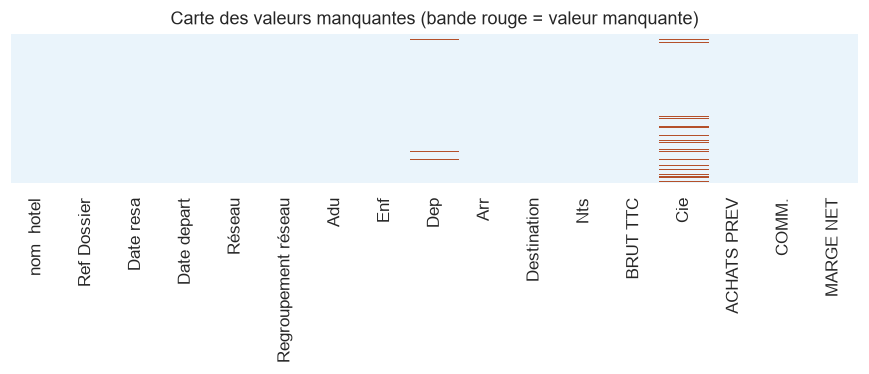

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(brut.isna(), cbar=False, yticklabels=False, cmap=["#EAF4FB", "#B4502A"], ax=ax)
ax.set_title("Carte des valeurs manquantes (bande rouge = valeur manquante)")
plt.tight_layout()
plt.show()

Deux colonnes sont concernées : le **code compagnie aérienne** (`Cie`) et le **code aéroport de départ** (`Dep`).
On approfondit ci-dessous *pourquoi* elles manquent, plutôt que de simplement le constater.

In [8]:
# La compagnie manque-t-elle plus souvent pour certains canaux de vente ?
brut.assign(cie_manquante=brut["Cie"].isna()).groupby("Regroupement réseau")["cie_manquante"].agg(
    dossiers="count", part_manquante="mean"
).assign(part_manquante=lambda d: (d["part_manquante"] * 100).round(1))

,dossiers,part_manquante
Regroupement réseau,,
B2B,13478,14.40
B2C,5072,1.90
GROUPES,77,0.00


**Interprétation :** si la part de compagnie manquante est nettement plus élevée sur un canal donné (par exemple
les ventes en direct ou en groupe, où le transport n'est parfois pas géré par NG Travel), l'absence de la donnée
s'explique par le modèle commercial et non par une erreur de saisie. C'est une distinction importante : on ne
traite pas de la même façon une donnée manquante *structurelle* et une donnée manquante *accidentelle*.

**Décision de traitement (appliquée en partie 6) :** ces valeurs manquantes ne sont **jamais supprimées** — une
ligne entière ne doit pas disparaître à cause d'une seule colonne incomplète. Elles sont explicitement
étiquetées `"NON RENSEIGNÉ"`, pour rester visibles et filtrables plutôt que silencieusement absentes.

## 3. Doublons

Un **doublon** est une ligne qui apparaît plusieurs fois. Deux définitions sont possibles, et elles ne donnent
pas nécessairement le même résultat :

- **Doublon strict** : toutes les colonnes sont identiques sur deux lignes ou plus.
- **Doublon métier** : la **clé métier** (ici `Ref Dossier`, censée être unique par dossier) est répétée, même
  si le reste de la ligne diffère — ce qui serait plus grave, car cela signifierait qu'un même identifiant de
  dossier a été utilisé deux fois pour des ventes différentes.

In [9]:
n_dup_stricts = brut.duplicated(keep=False).sum()
print(f"Lignes strictement dupliquées (toutes colonnes identiques) : {n_dup_stricts}")
if n_dup_stricts > 0:
    print("Aperçu des lignes concernées :")
    display(brut[brut.duplicated(keep=False)].sort_values(list(brut.columns)))

Lignes strictement dupliquées (toutes colonnes identiques) : 0


In [10]:
n_dup_ref = brut.duplicated(subset=["Ref Dossier"], keep=False).sum()
print(f"Références de dossier (Ref Dossier) apparaissant plus d'une fois : {n_dup_ref}")
if n_dup_ref > 0:
    print("Aperçu des dossiers concernés :")
    display(brut[brut.duplicated(subset=['Ref Dossier'], keep=False)].sort_values("Ref Dossier").head(10))

Références de dossier (Ref Dossier) apparaissant plus d'une fois : 0


**Interprétation :** si les deux compteurs ci-dessus sont à zéro, la base ne présente aucun doublon, ni au sens
strict ni au sens métier — la clé `Ref Dossier` joue bien son rôle d'identifiant unique et peut être utilisée
sans risque pour compter des dossiers (`nunique()`, jointures, etc.). Si un doublon métier existait sans être un
doublon strict, cela signalerait une **anomalie de gestion** à investiguer avant toute analyse (par exemple deux
lignes de vente différentes partageant par erreur la même référence).

In [11]:
# Vérification croisée : le nombre de références uniques correspond-il au nombre de lignes ?
print(f"Nombre de lignes ....................... {len(brut):,}".replace(",", " "))
print(f"Nombre de références de dossier uniques  {brut['Ref Dossier'].nunique():,}".replace(",", " "))

Nombre de lignes ....................... 18 627
Nombre de références de dossier uniques  18 627


## 4. Cardinalité des variables catégorielles

La **cardinalité** d'une colonne, c'est son nombre de valeurs différentes (`nunique()`). C'est une vérification
de bon sens avant toute analyse par catégorie : une colonne "Destination" avec 500 valeurs différentes
signalerait probablement des libellés mal harmonisés (ex. "RHODES" et "Rhodes " comptés comme deux destinations
distinctes), pas 500 vraies destinations.

In [12]:
colonnes_categorielles = ["nom  hotel", "Réseau", "Regroupement réseau", "Dep", "Arr", "Destination", "Cie"]
cardinalite = brut[colonnes_categorielles].nunique().rename("valeurs_distinctes").to_frame()
cardinalite["exemple_valeurs"] = [
    ", ".join(map(str, brut[c].dropna().unique()[:4])) + " ..." for c in colonnes_categorielles
]
cardinalite

,valeurs_distinctes,exemple_valeurs
nom hotel,24,"HOTEL 20, HOTEL 8, HOTEL 15, HOTEL 19 ..."
Réseau,66,"SA, CRELCEL, MACOMORP, TJ ..."
Regroupement réseau,3,"B2B, B2C, GROUPES ..."
Dep,46,"BRU, NTE, PAR, BOD ..."
Arr,6,"RHO, HER, ATH, SKG ..."
Destination,5,"RHODES, CRETE, GRECE CONTINENTALE, THESSALONIQ..."
Cie,28,"FR, TO, GQ, U2 ..."


**Lecture :** `Regroupement réseau` (3 valeurs attendues : B2B / B2C / Groupes) et `Destination` (5 destinations
grecques attendues) doivent avoir une cardinalité **faible et connue à l'avance** — un chiffre plus élevé serait
le signe d'un problème de saisie à corriger avant toute agrégation. `Réseau` et `nom  hotel`, en revanche, sont
attendus avec une cardinalité plus élevée (nombreux réseaux et hôtels distincts).

In [13]:
print("Valeurs de « Regroupement réseau » :", sorted(brut["Regroupement réseau"].dropna().unique()))
print("Valeurs de « Destination »         :", sorted(brut["Destination"].dropna().unique()))

Valeurs de « Regroupement réseau » : ['B2B', 'B2C', 'GROUPES']
Valeurs de « Destination »         : ['CORFU', 'CRETE', 'GRECE CONTINENTALE', 'RHODES', 'THESSALONIQUE']


## 5. Statistiques descriptives des variables numériques

Pour chaque variable chiffrée, `describe()` donne 8 indicateurs. Voici ce que chacun signifie, en langage
simple, avant de les lire sur nos données :

| Statistique | Signification |
|---|---|
| `count` | Nombre de valeurs non manquantes prises en compte |
| `mean` | **Moyenne** : somme des valeurs divisée par leur nombre |
| `std` | **Écart-type** : dispersion moyenne des valeurs autour de la moyenne (plus il est grand, plus les valeurs sont étalées) |
| `min` | Valeur la plus petite observée |
| `25%` | **1ᵉʳ quartile** : 25 % des valeurs sont inférieures à ce seuil |
| `50%` | **Médiane** : valeur qui sépare les données en deux moitiés égales (50 % au-dessus, 50 % en dessous) |
| `75%` | **3ᵉ quartile** : 75 % des valeurs sont inférieures à ce seuil |
| `max` | Valeur la plus grande observée |

In [14]:
colonnes_numeriques = ["Adu", "Enf", "Nts", "BRUT TTC", "ACHATS PREV", "COMM.", "MARGE NET"]
brut[colonnes_numeriques].describe().T

,count,mean,std,min,25%,50%,75%,max
Adu,18 627.00,2.43,1.16,0.00,2.00,2.00,2.00,22.00
Enf,18 627.00,0.19,0.54,0.00,0.00,0.00,0.00,9.00
Nts,18 627.00,7.75,2.47,0.00,7.00,7.00,9.00,56.00
BRUT TTC,18 627.00,3 388.60,2 611.63,0.00,1 830.00,2 612.00,4 038.00,58 950.00
ACHATS PREV,18 627.00,2 702.97,1 830.13,0.00,1 616.54,2 161.90,3 221.60,39 500.06
COMM.,18 627.00,344.11,411.11,0.00,0.00,269.76,475.14,6 541.91
MARGE NET,18 627.00,341.52,761.21,-8 734.50,-27.06,182.90,516.80,19 449.94


**Un réflexe essentiel : comparer `mean` (moyenne) et `50%` (médiane).** Si elles sont proches, la variable est
plutôt symétrique. Si la moyenne est nettement supérieure à la médiane, c'est le signe d'une **distribution
asymétrique tirée vers le haut** : quelques dossiers à très forte valeur tirent la moyenne vers le haut, alors
que la majorité des dossiers se situe plus bas. Ce point est central pour la partie 8 (« où utiliser la
moyenne »).

On mesure cette asymétrie précisément avec le **coefficient de skewness** (asymétrie) : proche de 0 = symétrique,
positif = étalée vers les valeurs hautes, négatif = étalée vers les valeurs basses.

In [15]:
asymetrie = brut[colonnes_numeriques].skew().rename("skewness (asymétrie)").to_frame()
asymetrie["lecture"] = np.where(
    asymetrie["skewness (asymétrie)"] > 0.5, "étalée vers le haut (valeurs extrêmes hautes)",
    np.where(asymetrie["skewness (asymétrie)"] < -0.5, "étalée vers le bas", "plutôt symétrique")
)
asymetrie

,skewness (asymétrie),lecture
Adu,3.34,étalée vers le haut (valeurs extrêmes hautes)
Enf,3.58,étalée vers le haut (valeurs extrêmes hautes)
Nts,1.63,étalée vers le haut (valeurs extrêmes hautes)
BRUT TTC,3.62,étalée vers le haut (valeurs extrêmes hautes)
ACHATS PREV,3.27,étalée vers le haut (valeurs extrêmes hautes)
COMM.,2.93,étalée vers le haut (valeurs extrêmes hautes)
MARGE NET,3.59,étalée vers le haut (valeurs extrêmes hautes)


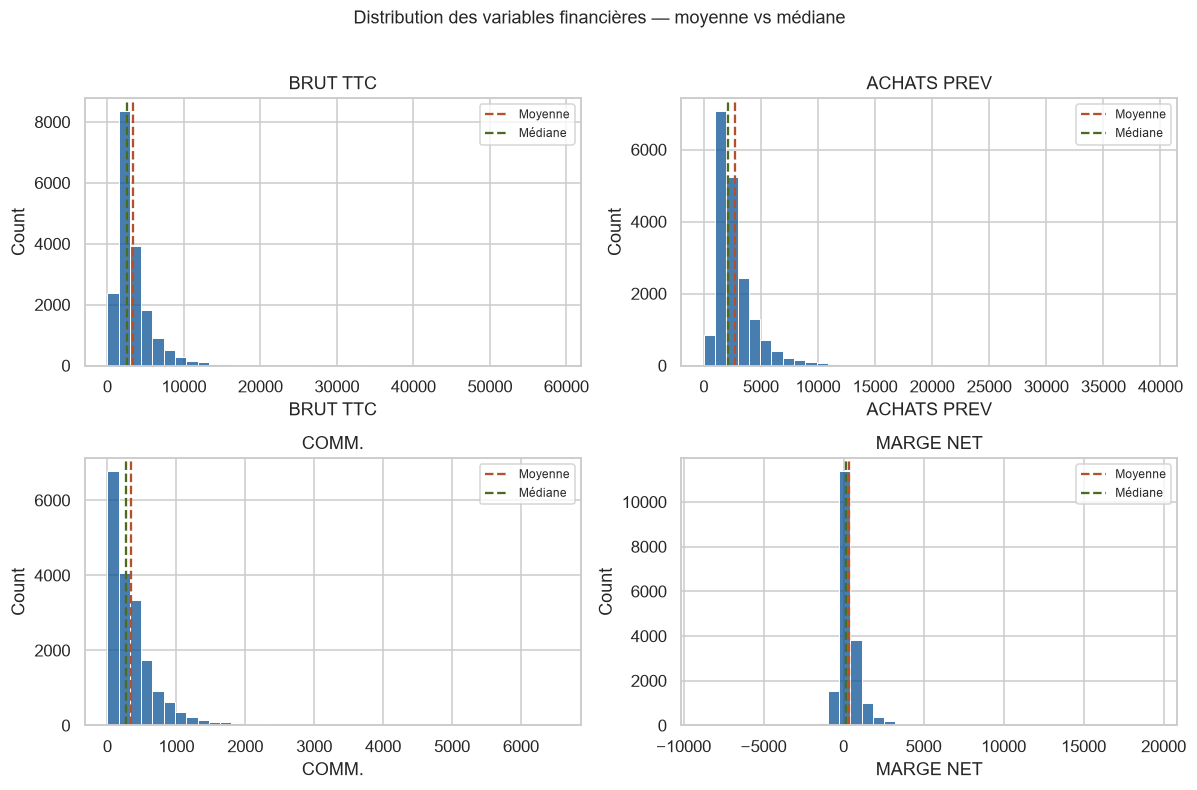

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, ["BRUT TTC", "ACHATS PREV", "COMM.", "MARGE NET"]):
    sns.histplot(brut[col], bins=40, color="#0B5394", ax=ax)
    ax.axvline(brut[col].mean(), color="#B4502A", linestyle="--", linewidth=1.5, label="Moyenne")
    ax.axvline(brut[col].median(), color="#4D6B1F", linestyle="--", linewidth=1.5, label="Médiane")
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle("Distribution des variables financières — moyenne vs médiane", y=1.02)
plt.tight_layout()
plt.show()

### Détection des valeurs extrêmes (méthode IQR)

La méthode la plus utilisée pour repérer des valeurs extrêmes (*outliers*) est la règle de l'**écart
interquartile (IQR)** : `IQR = Q3 - Q1`. Toute valeur en dehors de `[Q1 - 1.5×IQR ; Q3 + 1.5×IQR]` est considérée
comme statistiquement extrême. **Attention :** une valeur extrême n'est pas forcément une erreur — sur un
tour-opérateur, un très long séjour ou une réservation de groupe à très fort montant peuvent être des cas réels
et légitimes. Cette méthode sert à **repérer** ce qui mérite un regard, pas à supprimer automatiquement.

In [17]:
def compter_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((serie < borne_basse) | (serie > borne_haute)).sum()
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "borne_basse": borne_basse, "borne_haute": borne_haute,
        "nb_valeurs_extremes": n_out, "pct_valeurs_extremes": round(n_out / len(serie) * 100, 2),
    })

pd.DataFrame({col: compter_outliers_iqr(brut[col].dropna()) for col in ["Nts", "BRUT TTC", "ACHATS PREV", "MARGE NET"]}).T

,Q1,Q3,IQR,borne_basse,borne_haute,nb_valeurs_extremes,pct_valeurs_extremes
Nts,7.00,9.00,2.00,4.00,12.00,1 835.00,9.85
BRUT TTC,1 830.00,4 038.00,2 208.00,-1 482.00,7 350.00,1 259.00,6.76
ACHATS PREV,1 616.54,3 221.60,1 605.06,-791.06,5 629.20,1 205.00,6.47
MARGE NET,-27.06,516.80,543.86,-842.84,1 332.58,1 550.00,8.32


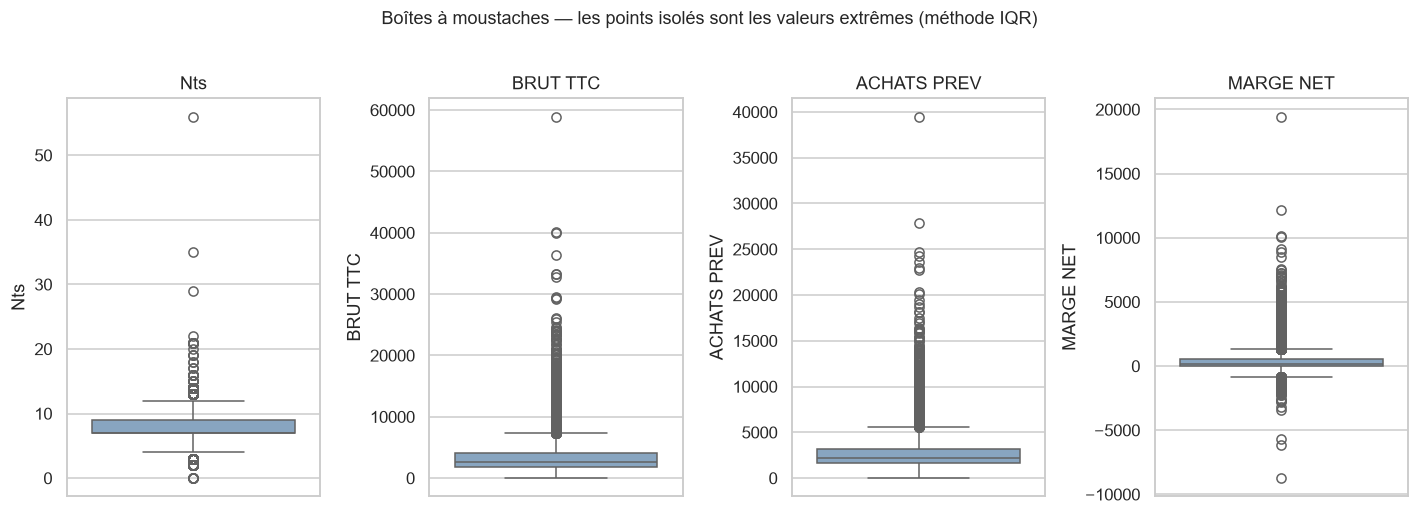

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
for ax, col in zip(axes, ["Nts", "BRUT TTC", "ACHATS PREV", "MARGE NET"]):
    sns.boxplot(y=brut[col], ax=ax, color="#7FA6C9")
    ax.set_title(col)
fig.suptitle("Boîtes à moustaches — les points isolés sont les valeurs extrêmes (méthode IQR)", y=1.03)
plt.tight_layout()
plt.show()

**Interprétation :** un pourcentage de valeurs extrêmes de quelques points n'est pas alarmant sur des données de
vente réelles — les séjours longs, les grands groupes ou les dossiers premium existent légitimement. Ce contrôle
sert avant tout à s'assurer qu'il n'y a pas de valeur *aberrante* (ex. un montant négatif improbable, un nombre
de nuits à 0 ou à 300) qui trahirait une erreur de saisie plutôt qu'un cas réel. C'est vérifié explicitement en
partie 7.

## 6. Nettoyage et enrichissement (ETL) — pas à pas

On applique maintenant **la fonction réellement utilisée en production** par l'application Streamlit et le
pipeline ETL (`etl/transformation/Transformation.py`), plutôt que de réécrire une logique séparée dans ce
notebook. Ainsi, tout ce qui est montré ici correspond exactement à ce que voit l'utilisateur final de
l'application.

In [19]:
from etl.transformation.Transformation import transformer_dataframe

df = transformer_dataframe(brut.copy())
print(f"Avant transformation : {brut.shape[0]:,} lignes x {brut.shape[1]} colonnes".replace(",", " "))
print(f"Après transformation : {df.shape[0]:,} lignes x {df.shape[1]} colonnes".replace(",", " "))
print(f"Colonnes ajoutées : {df.shape[1] - brut.shape[1]}  (aucune ligne supprimée)")

Avant transformation : 18 627 lignes x 17 colonnes
Après transformation : 18 627 lignes x 41 colonnes
Colonnes ajoutées : 24  (aucune ligne supprimée)


### 6.1 — Renommage des colonnes

Les noms bruts (parfois avec des espaces doubles ou des abréviations peu explicites, comme `nom  hotel` ou
`BRUT TTC`) sont renommés en `snake_case` explicite, plus sûr à manipuler en code et plus lisible.

In [20]:
renommage = pd.DataFrame({
    "colonne brute": ["nom  hotel", "Ref Dossier", "Date resa", "Date depart", "Réseau",
                        "Regroupement réseau", "Adu", "Enf", "Dep", "Arr", "Destination", "Nts",
                        "BRUT TTC", "Cie", "ACHATS PREV", "COMM.", "MARGE NET"],
    "colonne renommée": ["hotel", "ref_dossier", "date_resa", "date_depart", "reseau",
                           "regroupement_reseau", "adultes", "enfants", "aeroport_depart", "aeroport_arrivee",
                           "destination", "nuits", "ca_brut_ttc", "compagnie", "achats_prev", "commission",
                           "marge_nette"],
})
renommage

,colonne brute,colonne renommée
0,nom hotel,hotel
1,Ref Dossier,ref_dossier
2,Date resa,date_resa
3,Date depart,date_depart
4,Réseau,reseau
5,Regroupement réseau,regroupement_reseau
6,Adu,adultes
7,Enf,enfants
8,Dep,aeroport_depart
9,Arr,aeroport_arrivee


### 6.2 — Typage strict

`date_resa` et `date_depart` sont converties en véritables dates (`datetime64`) — condition indispensable pour
pouvoir calculer un nombre de jours entre les deux. Les colonnes de comptage (`adultes`, `enfants`, `nuits`)
sont forcées en entiers, les montants en décimaux.

In [21]:
avant_apres_types = pd.DataFrame({
    "type avant (brut)": brut[["Date resa", "Date depart", "Adu", "BRUT TTC"]].dtypes.astype(str).values,
    "type après (transformé)": df[["date_resa", "date_depart", "adultes", "ca_brut_ttc"]].dtypes.astype(str).values,
}, index=["date_resa", "date_depart", "adultes", "ca_brut_ttc"])
avant_apres_types

,type avant (brut),type après (transformé)
date_resa,datetime64[us],datetime64[us]
date_depart,datetime64[us],datetime64[us]
adultes,int64,int64
ca_brut_ttc,float64,float64


### 6.3 — Traitement des valeurs manquantes identifiées en partie 2

Conformément à la décision prise en partie 2 : aucune ligne n'est supprimée. Les codes `compagnie` et
`aeroport_depart` manquants sont remplacés par le libellé explicite `"NON RENSEIGNÉ"`, qui reste filtrable dans
l'application plutôt que silencieusement absent.

In [22]:
print("Valeurs manquantes dans « compagnie » après transformation :", df["compagnie"].isna().sum())
print("Répartition de la colonne « compagnie » (extrait) :")
df["compagnie"].value_counts().head(3).to_frame(name="nb_dossiers")

Valeurs manquantes dans « compagnie » après transformation : 0
Répartition de la colonne « compagnie » (extrait) :


,nb_dossiers
compagnie,
TO,7001
U2,3181
V7,2054


### 6.4 — Variables dérivées : formule, et vérification manuelle sur un dossier réel

Chaque nouvelle variable est calculée par une formule explicite. Pour être certain qu'elle fait bien ce qu'elle
prétend faire, on la recalcule **à la main** sur un dossier réel de la base et on compare au résultat produit
par le code.

In [23]:
exemple = df.iloc[0]
print("Dossier examiné :", exemple["ref_dossier"])
print()

print("• nb_pax = adultes + enfants")
print(f"    {exemple['adultes']} + {exemple['enfants']} = {exemple['adultes'] + exemple['enfants']}"
      f"   |  valeur stockée : {exemple['nb_pax']}   =>  {'OK' if exemple['adultes'] + exemple['enfants'] == exemple['nb_pax'] else 'ECART'}")
print()

delai_calc = (exemple["date_depart"] - exemple["date_resa"]).days
print("• delai_resa_jours = date_depart - date_resa")
print(f"    {exemple['date_depart'].date()} - {exemple['date_resa'].date()} = {delai_calc} jours"
      f"   |  valeur stockée : {exemple['delai_resa_jours']}   =>  {'OK' if delai_calc == exemple['delai_resa_jours'] else 'ECART'}")
print()

marge_pct_calc = exemple["marge_nette"] / exemple["ca_brut_ttc"]
print("• marge_pct = marge_nette / ca_brut_ttc")
print(f"    {exemple['marge_nette']:.2f} / {exemple['ca_brut_ttc']:.2f} = {marge_pct_calc:.4f}"
      f"   |  valeur stockée : {exemple['marge_pct']:.4f}   =>  {'OK' if abs(marge_pct_calc - exemple['marge_pct']) < 1e-9 else 'ECART'}")
print()

prix_pax_calc = exemple["ca_brut_ttc"] / exemple["nb_pax"]
print("• prix_moyen_pax = ca_brut_ttc / nb_pax")
print(f"    {exemple['ca_brut_ttc']:.2f} / {exemple['nb_pax']} = {prix_pax_calc:.2f}"
      f"   |  valeur stockée : {exemple['prix_moyen_pax']:.2f}   =>  {'OK' if abs(prix_pax_calc - exemple['prix_moyen_pax']) < 1e-6 else 'ECART'}")
print()

marge_recalc = exemple["ca_brut_ttc"] - exemple["achats_prev"] - exemple["commission"]
print("• écart comptable = |marge_nette - (ca_brut_ttc - achats_prev - commission)|")
print(f"    |{exemple['marge_nette']:.2f} - {marge_recalc:.2f}| = {abs(exemple['marge_nette'] - marge_recalc):.4f}"
      f"   |  valeur stockée : {exemple['ecart_comptable']:.4f}   =>  cohérent : {exemple['coherence_comptable']}")

Dossier examiné : 336848AA33

• nb_pax = adultes + enfants
    2 + 0 = 2   |  valeur stockée : 2   =>  OK

• delai_resa_jours = date_depart - date_resa
    2025-04-01 - 2025-01-23 = 68 jours   |  valeur stockée : 68   =>  OK

• marge_pct = marge_nette / ca_brut_ttc
    82.88 / 768.00 = 0.1079   |  valeur stockée : 0.1079   =>  OK

• prix_moyen_pax = ca_brut_ttc / nb_pax
    768.00 / 2 = 384.00   |  valeur stockée : 384.00   =>  OK

• écart comptable = |marge_nette - (ca_brut_ttc - achats_prev - commission)|
    |82.88 - 82.88| = 0.0000   |  valeur stockée : 0.0000   =>  cohérent : True


### 6.5 — Catégorisations : les seuils exacts utilisés

Trois variables de catégorisation transforment une valeur continue en tranche lisible. Voici les seuils exacts
codés dans la fonction de transformation (aucune approximation) :

**`tranche_delai`** (délai entre réservation et départ, en jours) :

| Condition | Catégorie |
|---|---|
| `delai < 0` | Anomalie (`<0`) — réservation enregistrée après la date de départ |
| `0 ≤ delai ≤ 14` | Last minute (0-14 j) |
| `15 ≤ delai ≤ 30` | Court (15-30 j) |
| `31 ≤ delai ≤ 60` | Moyen (31-60 j) |
| `61 ≤ delai ≤ 120` | Long (61-120 j) |
| `delai > 120` | Très anticipé (>120 j) |

**`tranche_duree`** (nombre de nuits du séjour) :

| Condition | Catégorie |
|---|---|
| `nuits ≤ 4` | Court séjour (≤4 nuits) |
| `5 ≤ nuits ≤ 8` | Semaine (5-8 nuits) |
| `nuits > 8` | Long séjour (>8 nuits) |

**`saison_touristique`** (mois de départ) :

| Mois | Catégorie |
|---|---|
| Juillet, août | Haute saison |
| Juin, septembre | Épaule |
| Avril, mai, octobre | Basse saison |
| Autres mois | Hors saison |

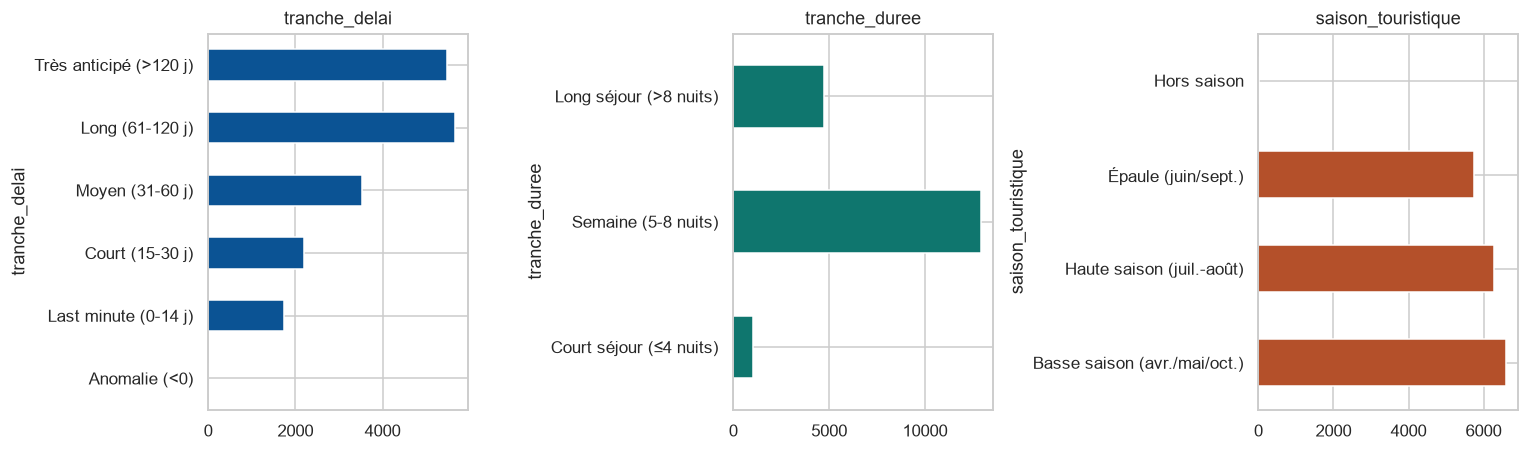

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ordre_delai = ["Anomalie (<0)", "Last minute (0-14 j)", "Court (15-30 j)", "Moyen (31-60 j)",
               "Long (61-120 j)", "Très anticipé (>120 j)"]
df["tranche_delai"].value_counts().reindex(ordre_delai).dropna().plot.barh(ax=axes[0], color="#0B5394")
axes[0].set_title("tranche_delai")

ordre_duree = ["Court séjour (≤4 nuits)", "Semaine (5-8 nuits)", "Long séjour (>8 nuits)"]
df["tranche_duree"].value_counts().reindex(ordre_duree).dropna().plot.barh(ax=axes[1], color="#0F766E")
axes[1].set_title("tranche_duree")

df["saison_touristique"].value_counts().plot.barh(ax=axes[2], color="#B4502A")
axes[2].set_title("saison_touristique")

plt.tight_layout()
plt.show()

**Point de vigilance :** la catégorie *Anomalie (<0)* signale des dossiers où la date de réservation enregistrée
est postérieure à la date de départ — chronologiquement impossible. Le code ne les supprime pas mais les
étiquette : c'est l'un des critères qui fait basculer un dossier en `valide = False` (voir partie 7).

In [25]:
n_anomalies = (df["tranche_delai"] == "Anomalie (<0)").sum()
print(f"Dossiers en anomalie de délai (date de résa postérieure à la date de départ) : {n_anomalies}")
if n_anomalies > 0:
    df.loc[df["tranche_delai"] == "Anomalie (<0)",
           ["ref_dossier", "date_resa", "date_depart", "delai_resa_jours"]].head(5)

Dossiers en anomalie de délai (date de résa postérieure à la date de départ) : 1


## 7. Contrôle qualité après transformation

Deux contrôles indépendants sont posés par la transformation, et il est important de ne pas les confondre :

- **`coherence_comptable`** : la comptabilité du dossier est-elle juste ? (la marge nette correspond-elle à
  `ca_brut_ttc - achats_prev - commission`, à 0,05 € près pour absorber les arrondis ?)
- **`valide`** : le dossier est-il *exploitable pour les indicateurs agrégés* (CA, marge, KPI) ? Un dossier peut
  être comptablement cohérent mais invalide (ex. nombre de nuits à 0), ou l'inverse.

In [26]:
taux_coherent = df["coherence_comptable"].mean() * 100
taux_valide = df["valide"].mean() * 100
print(f"Dossiers comptablement cohérents ......... {taux_coherent:.2f} %  ({df['coherence_comptable'].sum():,} / {len(df):,})".replace(",", " "))
print(f"Dossiers valides pour les indicateurs .... {taux_valide:.2f} %  ({df['valide'].sum():,} / {len(df):,})".replace(",", " "))

Dossiers comptablement cohérents ......... 100.00 %  (18 627 / 18 627)
Dossiers valides pour les indicateurs .... 99.91 %  (18 610 / 18 627)


In [27]:
# Les deux contrôles se recoupent-ils ? Table croisée cohérence x validité
pd.crosstab(df["coherence_comptable"], df["valide"],
            rownames=["coherence_comptable"], colnames=["valide"], margins=True, margins_name="Total")

valide,False,True,Total
coherence_comptable,,,
True,17,18610,18627
Total,17,18610,18627


### Détail des critères de validité

`valide` combine 6 conditions simultanées. Pour comprendre *pourquoi* les quelques dossiers invalides le sont,
on vérifie chaque condition séparément plutôt que de se contenter du résultat global.

In [28]:
criteres = pd.DataFrame({
    "ca_brut_ttc > 0": df["ca_brut_ttc"] > 0,
    "nb_pax > 0": df["nb_pax"] > 0,
    "nuits > 0": df["nuits"] > 0,
    "delai_resa_jours >= 0": df["delai_resa_jours"] >= 0,
    "date_depart renseignée": df["date_depart"].notna(),
    "date_resa renseignée": df["date_resa"].notna(),
})

# Sur les dossiers invalides uniquement : quel(s) critère(s) échouent ?
invalides = criteres[~df["valide"]]
print(f"Nombre de dossiers invalides : {len(invalides)}")
if len(invalides) > 0:
    (~invalides).sum().rename("nb_dossiers_en_echec_sur_ce_critere").to_frame()

Nombre de dossiers invalides : 17


### Doublons et valeurs manquantes après transformation

Une dernière vérification : la transformation n'a-t-elle pas *introduit* de doublons ou de valeurs manquantes
inattendues ?

In [29]:
print(f"Doublons stricts après transformation : {df.duplicated(keep=False).sum()}")
print(f"Doublons sur ref_dossier après transformation : {df.duplicated(subset=['ref_dossier'], keep=False).sum()}")
print()
manquants_apres = df.isna().sum()
manquants_apres = manquants_apres[manquants_apres > 0]
if manquants_apres.empty:
    print("Aucune valeur manquante (NaN) après transformation — les cas identifiés en partie 2 sont désormais")
    print('étiquetés explicitement (« NON RENSEIGNÉ ») plutôt que laissés en NaN.')
else:
    print("Colonnes encore concernées par des NaN après transformation :")
    display(manquants_apres.to_frame(name="nb_valeurs_manquantes"))

Doublons stricts après transformation : 0
Doublons sur ref_dossier après transformation : 0

Colonnes encore concernées par des NaN après transformation :


,nb_valeurs_manquantes
marge_pct,16
taux_commission,16
prix_moyen_pax,6
prix_moyen_pax_nuit,6


**Décision retenue pour la suite du notebook :** les analyses métier (parties 8 et 9) se concentrent sur le
périmètre `valide = True`, pour ne pas fausser des indicateurs agrégés (CA, marge) avec des lignes chronologiquement
incohérentes ou à zéro passager. Ce périmètre reste **la quasi-totalité de la base**, comme le montre le taux
calculé plus haut — aucune donnée n'est perdue silencieusement, le filtre est explicite et traçable.

In [30]:
df_f = df[df["valide"]].copy()
print(f"Périmètre retenu pour l'analyse : {len(df_f):,} / {len(df):,} dossiers ({len(df_f)/len(df)*100:.1f} %)".replace(",", " "))

Périmètre retenu pour l'analyse : 18 610 / 18 627 dossiers (99.9 %)


## 8. Où et comment utiliser la moyenne ?

La moyenne est l'indicateur le plus utilisé — et le plus souvent mal utilisé. Trois pièges concrets, démontrés
ci-dessous sur nos propres données.

### 8.1 — Piège n°1 : moyenner un pourcentage sans pondérer

`marge_pct` est déjà un ratio (marge / CA) calculé **par dossier**. Faire la **moyenne simple** de ces ratios
par destination n'est pas la même chose que calculer le **vrai taux de marge** de la destination
(`somme des marges / somme du CA`) — ces deux calculs peuvent diverger si les dossiers n'ont pas tous le même
poids en euros.

In [31]:
comparaison = df_f.groupby("destination").apply(
    lambda g: pd.Series({
        "moyenne_simple_marge_pct": g["marge_pct"].mean(),
        "taux_marge_pondere": g["marge_nette"].sum() / g["ca_brut_ttc"].sum(),
        "nb_dossiers": len(g),
    }), include_groups=False
)
comparaison["ecart_points"] = (comparaison["moyenne_simple_marge_pct"] - comparaison["taux_marge_pondere"]) * 100
comparaison.sort_values("ecart_points", key=abs, ascending=False)

,moyenne_simple_marge_pct,taux_marge_pondere,nb_dossiers,ecart_points
destination,,,,
THESSALONIQUE,0.06,0.11,712.00,-4.99
CRETE,0.05,0.10,11 228.00,-4.96
CORFU,0.02,0.07,1 749.00,-4.51
GRECE CONTINENTALE,0.05,0.08,2 943.00,-3.60
RHODES,0.10,0.12,1 978.00,-2.42


**Lecture :** la colonne `ecart_points` montre l'écart, en points de pourcentage, entre les deux méthodes de
calcul. Un écart proche de 0 indique que les dossiers de la destination pèsent à peu près le même montant ; un
écart plus marqué signale que quelques dossiers à fort ou faible montant tirent la moyenne simple dans une
direction que la réalité économique (pondérée par l'euro réellement vendu) ne reflète pas.

**Règle à retenir :** pour un taux (marge %, taux de commission, taux de conversion...), la question à se poser
avant de moyenner est toujours *« est-ce que je dois pondérer par le volume sous-jacent ? »* — la réponse est
quasi toujours oui dès qu'on agrège au niveau d'un groupe (destination, réseau, mois...).

### 8.2 — Piège n°2 : moyenne sur une distribution asymétrique

Comme observé en partie 5 (`skew()`), les montants financiers (`ca_brut_ttc`, `marge_nette`) sont étalés vers le
haut : quelques gros dossiers tirent la moyenne au-dessus de ce que vit la majorité des dossiers.

In [32]:
for col in ["ca_brut_ttc", "delai_resa_jours"]:
    moyenne, mediane = df_f[col].mean(), df_f[col].median()
    ecart_pct = (moyenne - mediane) / mediane * 100
    print(f"{col:20s}  moyenne = {moyenne:>12,.1f}   médiane = {mediane:>12,.1f}   "
          f"écart = {ecart_pct:+.1f} % (moyenne vs médiane)".replace(",", " "))

ca_brut_ttc           moyenne =      3 391.5   médiane =      2 614.0   écart = +29.7 % (moyenne vs médiane)
delai_resa_jours      moyenne =         91.0   médiane =         78.0   écart = +16.7 % (moyenne vs médiane)


**Règle à retenir :** quand moyenne et médiane divergent nettement, préférer **communiquer les deux**, ou la
médiane seule si on veut décrire *"le dossier typique"* plutôt que *"le dossier moyen"* (qui peut ne ressembler
à presque aucun dossier réel dans une distribution très étalée).

### 8.3 — Quand la moyenne (ou la somme) est-elle le bon outil ?

| Question métier | Bon indicateur | Pourquoi |
|---|---|---|
| "Combien de CA a-t-on généré au total ?" | **Somme** | On veut un volume total, pas une moyenne |
| "Quel est le taux de marge global d'une destination ?" | **Moyenne pondérée** (`somme marge / somme CA`) | Évite le piège 8.1 |
| "Combien de passagers par dossier en moyenne ?" | **Moyenne simple** | `nb_pax` n'est pas un ratio, la moyenne simple est légitime |
| "Quel est le délai de réservation typique ?" | **Médiane** | Distribution étalée (piège 8.2), la médiane résiste mieux aux valeurs extrêmes |
| "Quel écart existe-t-il entre destinations sur un même indicateur ?" | **Moyenne + écart-type** (ou boîte à moustaches) | La moyenne seule ne dit rien sur la dispersion |

In [33]:
recap_destination = df_f.groupby("destination").agg(
    dossiers=("ref_dossier", "count"),
    ca_total=("ca_brut_ttc", "sum"),
    marge_totale=("marge_nette", "sum"),
    nb_pax_moyen=("nb_pax", "mean"),
    delai_median=("delai_resa_jours", "median"),
).assign(taux_marge_pondere=lambda d: d["marge_totale"] / d["ca_total"]).sort_values("ca_total", ascending=False)
recap_destination

,dossiers,ca_total,marge_totale,nb_pax_moyen,delai_median,taux_marge_pondere
destination,,,,,,
CRETE,11228,41 050 549.46,4 282 225.85,2.67,79.00,0.10
GRECE CONTINENTALE,2943,8 399 616.16,702 184.26,2.50,89.00,0.08
RHODES,1978,6 828 932.91,845 382.04,2.60,72.00,0.12
CORFU,1749,4 733 934.31,318 007.58,2.57,61.00,0.07
THESSALONIQUE,712,2 102 588.42,238 310.66,2.65,87.00,0.11


## 9. Analyse exploratoire orientée métier

Cette dernière partie applique les bonnes pratiques établies ci-dessus (sommes pour les volumes, moyennes
pondérées pour les taux, médiane si distribution étalée) aux grandes questions business du projet.

### 9.1 — KPIs globaux

In [34]:
ca = df_f["ca_brut_ttc"].sum()
marge = df_f["marge_nette"].sum()
marge_pct_global = marge / ca
pct_deficit = df_f["dossier_deficitaire"].mean()

print(f"CA brut total ............ {ca:>15,.0f} €".replace(",", " "))
print(f"Marge nette totale ....... {marge:>15,.0f} €".replace(",", " "))
print(f"Taux de marge global ..... {marge_pct_global*100:>14.1f} %   (moyenne pondérée : marge / CA)")
print(f"Dossiers déficitaires .... {pct_deficit*100:>14.1f} %")
print(f"Nombre de dossiers ....... {len(df_f):>15,}".replace(",", " "))
print(f"Passagers ................ {int(df_f['nb_pax'].sum()):>15,}".replace(",", " "))

CA brut total ............      63 115 621 €
Marge nette totale .......       6 386 110 €
Taux de marge global .....           10.1 %   (moyenne pondérée : marge / CA)
Dossiers déficitaires ....           28.0 %
Nombre de dossiers .......          18 610
Passagers ................          48 823


### 9.2 — Évolution temporelle : 2025 vs 2026

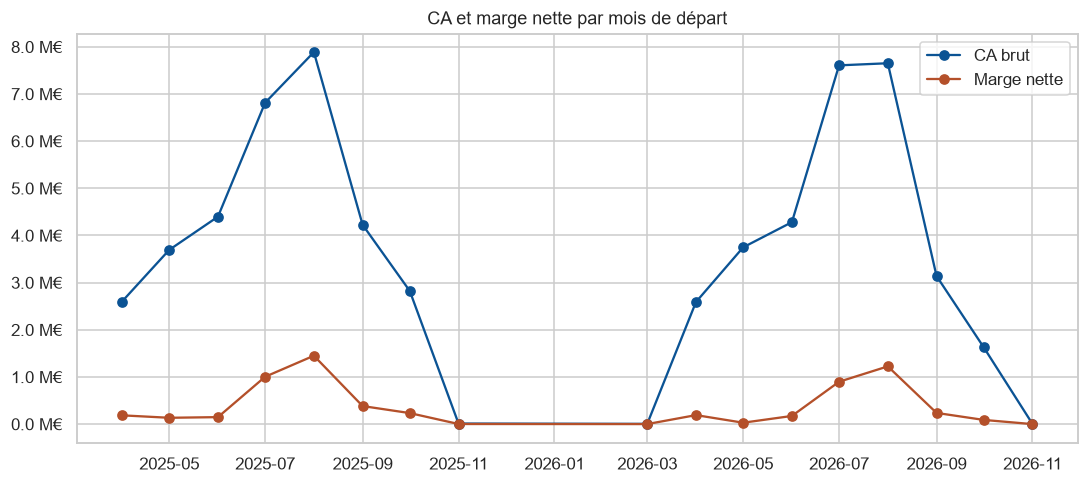

,ca,marge,dossiers,taux_marge
saison,,,,
2025,32 457 860.39,3 541 849.43,9628,0.11
2026,30 657 760.87,2 844 260.96,8982,0.09


In [35]:
mensuel = (df_f.groupby("mois_depart_periode")
           .agg(ca=("ca_brut_ttc", "sum"), marge=("marge_nette", "sum"), dossiers=("ref_dossier", "count"))
           .reset_index().sort_values("mois_depart_periode"))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(mensuel["mois_depart_periode"], mensuel["ca"], marker="o", label="CA brut", color="#0B5394")
ax.plot(mensuel["mois_depart_periode"], mensuel["marge"], marker="o", label="Marge nette", color="#B4502A")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
ax.set_title("CA et marge nette par mois de départ")
ax.legend()
plt.tight_layout()
plt.show()

df_f.groupby("saison").agg(ca=("ca_brut_ttc", "sum"), marge=("marge_nette", "sum"),
                            dossiers=("ref_dossier", "count")).assign(
    taux_marge=lambda d: d["marge"] / d["ca"])

*(La saison la plus récente peut être encore en cours de commercialisation au moment de l'extraction : toute
comparaison doit se lire à stade équivalent, pas en cumul brut.)*

### 9.3 — Performance par destination et par réseau

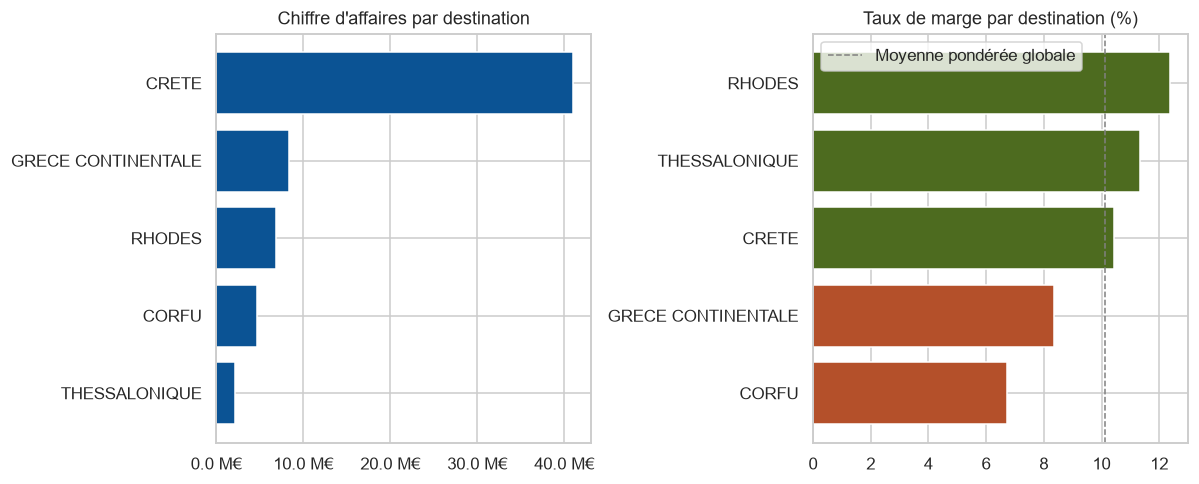

,dossiers,ca,marge,marge_pct
destination,,,,
CRETE,11228,41 050 549.46,4 282 225.85,0.10
GRECE CONTINENTALE,2943,8 399 616.16,702 184.26,0.08
RHODES,1978,6 828 932.91,845 382.04,0.12
CORFU,1749,4 733 934.31,318 007.58,0.07
THESSALONIQUE,712,2 102 588.42,238 310.66,0.11


In [36]:
dest = (df_f.groupby("destination")
        .agg(dossiers=("ref_dossier", "count"), ca=("ca_brut_ttc", "sum"), marge=("marge_nette", "sum"))
        .assign(marge_pct=lambda d: d["marge"] / d["ca"]).sort_values("ca", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
dest_ca = dest.sort_values("ca")
axes[0].barh(dest_ca.index, dest_ca["ca"], color="#0B5394")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
axes[0].set_title("Chiffre d'affaires par destination")

dest_marge = dest.sort_values("marge_pct")
couleurs = ["#B4502A" if v < marge_pct_global else "#4D6B1F" for v in dest_marge["marge_pct"]]
axes[1].barh(dest_marge.index, dest_marge["marge_pct"] * 100, color=couleurs)
axes[1].axvline(marge_pct_global * 100, color="grey", linestyle="--", linewidth=1, label="Moyenne pondérée globale")
axes[1].set_title("Taux de marge par destination (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

dest

In [37]:
canal = (df_f.groupby("regroupement_reseau")
         .agg(dossiers=("ref_dossier", "count"), ca=("ca_brut_ttc", "sum"),
              marge=("marge_nette", "sum"), commission=("commission", "sum"))
         .assign(marge_pct=lambda d: d["marge"] / d["ca"]))
canal

,dossiers,ca,marge,commission,marge_pct
regroupement_reseau,,,,,
B2B,13469,43 961 162.10,2 913 862.22,6 409 177.31,0.07
B2C,5064,18 871 394.78,3 386 466.01,0.00,0.18
GROUPES,77,283 064.38,85 782.16,0.00,0.30


### 9.4 — Corrélations entre variables numériques

Une matrice de corrélation résume, en un coup d'œil, la force du lien linéaire entre chaque paire de variables
numériques (de -1 = lien inverse parfait, à +1 = lien positif parfait, 0 = pas de lien linéaire détecté).

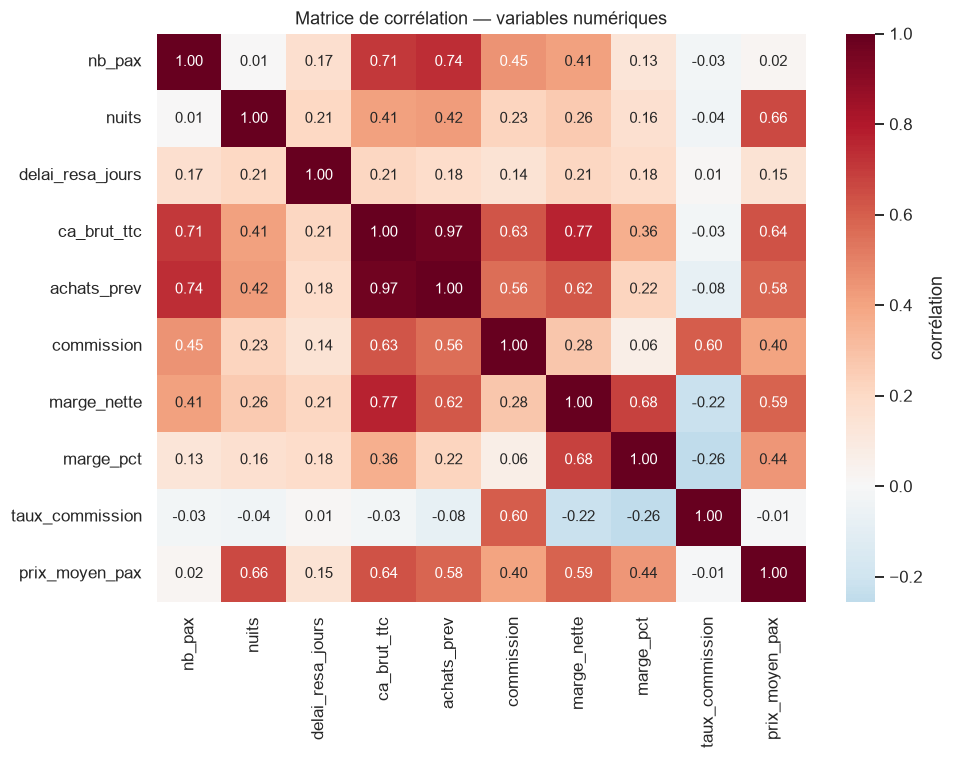

In [38]:
cols_corr = ["nb_pax", "nuits", "delai_resa_jours", "ca_brut_ttc", "achats_prev", "commission",
             "marge_nette", "marge_pct", "taux_commission", "prix_moyen_pax"]
correlation = df_f[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "corrélation"})
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()

**Lecture prudente :** une forte corrélation entre `ca_brut_ttc` et `achats_prev` est attendue (un séjour plus
cher coûte aussi plus cher à l'achat) et n'indique rien d'anormal. En revanche, une corrélation marquée entre
`delai_resa_jours` et `marge_pct` confirmerait visuellement le lien étudié en partie 9.6 ci-dessous — une
corrélation reste toutefois une mesure de lien statistique, pas une preuve de cause.

### 9.5 — Dossiers déficitaires

Marge détruite (cumul des dossiers déficitaires) : 1 306 856 €


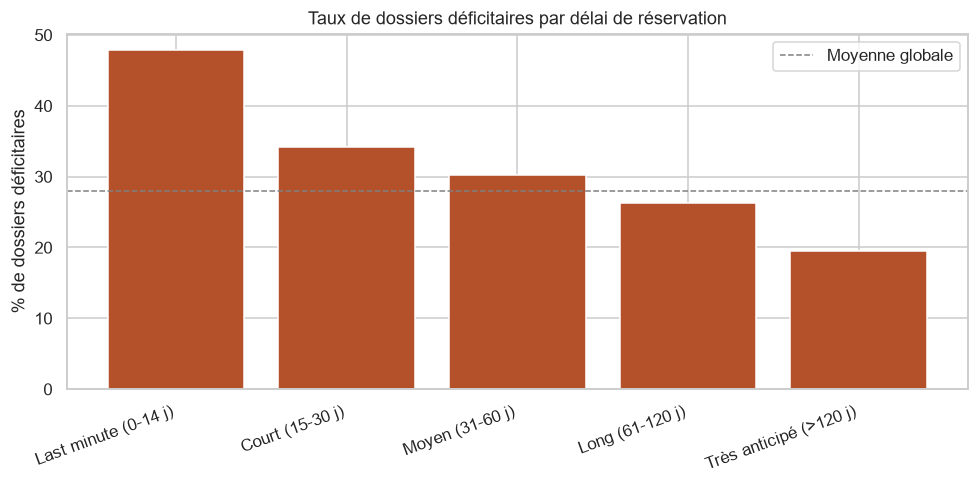

In [39]:
perte_totale = df_f.loc[df_f["marge_nette"] < 0, "marge_nette"].sum()
print(f"Marge détruite (cumul des dossiers déficitaires) : {abs(perte_totale):,.0f} €".replace(",", " "))

ordre_delai = ["Last minute (0-14 j)", "Court (15-30 j)", "Moyen (31-60 j)", "Long (61-120 j)", "Très anticipé (>120 j)"]
deficit_par_delai = (df_f.groupby("tranche_delai")["dossier_deficitaire"].mean() * 100).reindex(ordre_delai).dropna()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(deficit_par_delai.index, deficit_par_delai.values, color="#B4502A")
ax.axhline(pct_deficit * 100, color="grey", linestyle="--", linewidth=1, label="Moyenne globale")
ax.set_ylabel("% de dossiers déficitaires")
ax.set_title("Taux de dossiers déficitaires par délai de réservation")
plt.xticks(rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

### 9.6 — Délai de réservation et marge

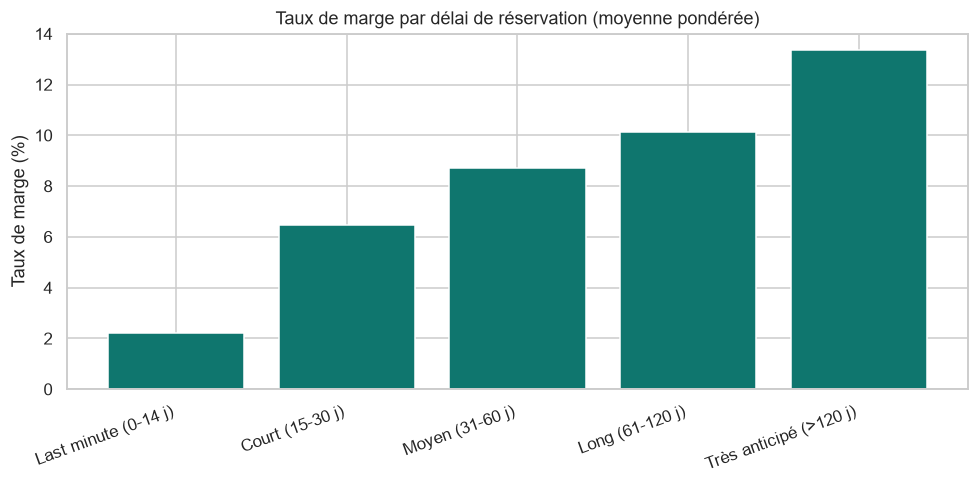

,ca,marge,dossiers,marge_pct
tranche_delai,,,,
Last minute (0-14 j),4 299 647.66,94 872.04,1742,0.02
Court (15-30 j),6 396 533.31,412 882.75,2197,0.06
Moyen (31-60 j),11 172 087.54,972 187.38,3536,0.09
Long (61-120 j),18 595 407.21,1 884 075.57,5667,0.10
Très anticipé (>120 j),22 651 945.54,3 022 092.64,5468,0.13


In [40]:
delai_marge = (df_f[df_f["tranche_delai"].isin(ordre_delai)]
               .groupby("tranche_delai")
               .agg(ca=("ca_brut_ttc", "sum"), marge=("marge_nette", "sum"), dossiers=("ref_dossier", "count"))
               .assign(marge_pct=lambda d: d["marge"] / d["ca"]).reindex(ordre_delai))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(delai_marge.index, delai_marge["marge_pct"] * 100, color="#0F766E")
ax.set_ylabel("Taux de marge (%)")
ax.set_title("Taux de marge par délai de réservation (moyenne pondérée)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

delai_marge

## 10. Synthèse

**Sur la donnée elle-même :**
- Base de départ propre : pas de doublon détecté (ni strict, ni sur la clé métier `Ref Dossier`), un seul champ
  significativement incomplet (`compagnie`, expliqué par le canal de vente), aucune ligne supprimée à aucune
  étape du traitement.
- 17 colonnes brutes enrichies à 41 colonnes, chaque variable calculée étant vérifiable formule par formule
  (partie 6.4).
- Plus de 99 % des dossiers sont valides pour les indicateurs agrégés ; les rares cas invalides sont identifiés
  et expliqués critère par critère, pas juste comptés (partie 7).

**Sur la méthode :**
- La distinction moyenne simple / moyenne pondérée / médiane n'est pas un détail théorique : elle change
  concrètement le classement des destinations par taux de marge (partie 8.1) et la lecture du délai de
  réservation typique (partie 8.2).

**Sur le métier :**
- Le taux de marge global (~10 %) et le taux de dossiers déficitaires (~28 %) confirment que le sujet n'est pas
  le volume de vente mais la **rentabilité** de ce volume — répartie inégalement selon la destination, le canal
  et le délai de réservation.

**Pour aller plus loin :** l'application Streamlit (simulateur de repricing, système de recommandation) et le
rapport de synthèse (`docs/Rapport_Projet_NG_Travel.pdf`) prolongent ces constats en recommandations opérationnelles.